In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import doc_retention_utils as dr
from lmfit import Model
from scipy.stats import chi2

# plt.style.use("ggplot")

# Notebook 5: Vollenweider versus exponential models fit to the E2017 lake data

Here we fit models to the E2017 lake data, including:
- Comparison of Vollenweider and exponential model fits
- Exploring the impact of dropping high WRT lakes: note how poor the transmission vs WRT plots look then...
- Look into net production lakes, where a similar model framework could apply (but this is a future to do).

# Load Evans data

In [2]:
data_fpath = r"data/input_data/evans_2017_doc_retention_cleaned.csv"
df = pd.read_csv(data_fpath)

df = df.rename({"WRT_yr": "tau"}, axis=1)
df.sort_values("tau", inplace=True)

# Drop any NANs in tau or R_DOC
df = df.dropna(how="any", subset=["tau", "R_DOC"])

# Calculate transmission
df["TDOC"] = 1 - df["R_DOC"]

# Drop negative retention values
# Evans et al. used RDOC threshold of 0.1.
df_neg = df.query("R_DOC <= -0.1")
df = df.query("R_DOC > 0.1")

df.head()

,Name,Latitude,Longitude,Country,Type,Nutrient Status,Catchment_area_ha,Waterbody area_ha,Volume_m3,Discharge_m_per_yr,...,DOCin,DOCout,DOCout/DOCin,R_DOC,T½,References,Notes,Type.1,Unnamed: 19,TDOC
26,Røynelandsvatn,58° 22ʹ N,08° 20ʹ E,Norway,Lake,Oligotrophic,130,3.5,123 000,0.95,...,6.37,5.491,0.861,0.139,0.46,"S7, S6",NaN,DOC sink,NaN,0.861
34,Black Esk,55° 15ʹ N,03° 15ʹ W,UK,Reservoir,Oligotrophic,1 813,33.5,3 147 000,1.49,...,9.25,7.303,0.789,0.211,0.34,S10,D,DOC sink,NaN,0.789
32,Gäddtjärn,59° 86ʹ N,15° 18ʹ E,Sweden,Lake,Oligotrophic,226,6.8,231 200,0.76,...,15.00,11.720,0.781,0.219,0.38,S8,NaN,DOC sink,NaN,0.781
20,Alinen Rautjarvi,61° 11ʹ N,25° 05ʹ E,Finland,Lake,Oligotrophic,6 600,50.0,2 100 000,0.24,...,2.90,2.394,0.825,0.175,0.48,34,NaN,DOC sink,NaN,0.825
47,Burr Oak,39° 31ʹ N,82° 60ʹ W,USA,Reservoir,Mesotrophic,8 600,270.0,12 150 000,0.76,...,2.13,1.458,0.686,0.314,0.48,S36,NaN,DOC sink,NaN,0.686


In [3]:
# df_neg

# Also load in newly gathered river data

In [4]:
riv_df = pd.read_csv(r'data/input_data/review_instream_doc_retention_summary.csv')
# Drop data associated with natural DOM addition experiments
riv_df = riv_df.loc[riv_df['Exclude_expts'] == 0]

riv_df.rename({'Transmission (M_out/M_in)': 'mo_mi'}, axis=1, inplace=True)
riv_df.head()

,Site,Lat,Lon,Country,mo_mi,t (days),Stream order,Ref,Exclude_expts,Comment
0,"Fluvià River, NE Spain",42.189200,2.767300,Spain,1.000000,0.250000,Reaches in 2nd-4th order streams,Casas-Ruiz et al. (2017),0,"Median of 12 sites, 10 samples/site"
1,"Wood Brook, England",52.800938,-2.305389,UK,0.982609,0.090981,2nd order,Khamis et al. (2021),0,NaN
2,"Creeping Swamp, North Carolina",35.415000,-77.193000,USA,0.360000,9.259259,3rd,Mulholland (1981),0,Coordinates are approximate
3,"Fort River, Massachusetts",42.336000,-72.574000,USA,0.960000,0.132331,4th,Fisher (1977),0,Coordinates are approximate
4,"Tianmu Lake catchment, SE China",31.222847,119.391676,China,0.713333,0.885580,1st-2nd order,Gong et al. (2021),0,"Average 3 sites, 2 samples/site"


# Fit Vollenweider and exponential models

We considered grouping the lakes e.g. by geoclimatic region, but for now we will consider all lakes as one, as done by previous authors.

In [5]:
print(len(df), "lakes in the TOC dataset.")

print("\n\nFit for 'Vollenweider, constant sigma'")
toc_fit1 = dr.fit_model(dr.transmission_sigma_constant, df, "tau", "TDOC")

print("\n\nFit for 'Vollenweider, time-varying sigma'")
toc_fit2 = dr.fit_model(dr.transmission_sigma_as_func_of_tau, df, "tau", "TDOC")

print("\n\nFit for 'exponential decay'")
toc_fit_exp1 = dr.fit_model(dr.transmission_k_constant, df, "tau", "TDOC")

print("\n\nFit for 'exponential decay'")
toc_fit_exp2 = dr.fit_model(dr.transmission_k_as_func_of_tau, df, "tau", "TDOC")

47 lakes in the TOC dataset.


Fit for 'Vollenweider, constant sigma'
[[Model]]
    Model(transmission_sigma_constant)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 47
    # variables        = 1
    chi-square         = 1.85195616
    reduced chi-square = 0.04025992
    Akaike info crit   = -149.993542
    Bayesian info crit = -148.143394
    R-squared          = -0.39808567
[[Variables]]
    sigma:  0.40120078 +/- 0.06025917 (15.02%) (init = 0.5)
R2: -0.37


Fit for 'Vollenweider, time-varying sigma'
[[Model]]
    Model(transmission_sigma_as_func_of_tau)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 19
    # data points      = 47
    # variables        = 2
    chi-square         = 0.68632560
    reduced chi-square = 0.01525168
    Akaike info crit   = -194.647884
    Bayesian info crit = -190.947589
    R-squared          = 0.48187651
[[Variables]]
    a:  0.65693710 +/- 0.05429155 (8.26%) (init 

## Plot

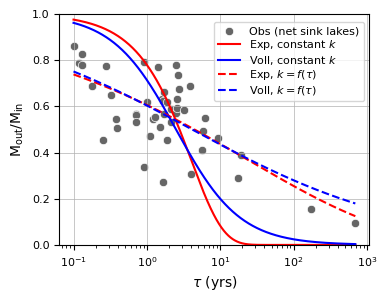

In [23]:
# Plot all models on one plot

fig, ax = plt.subplots(figsize=(4, 3))

# Plot observations
sn.scatterplot(data=df, x='tau', y='TDOC', color='0.4', label='Obs (net sink lakes)')

# Plot each model's fit
tau_values = np.linspace(df['tau'].min(), df['tau'].max(), 100000)
ax.plot(tau_values, toc_fit_exp1.eval(tau=tau_values), label='Exp, constant $k$', color='red')
ax.plot(tau_values, toc_fit1.eval(tau=tau_values), label=r'Voll, constant $k$', color='blue')
ax.plot(tau_values, toc_fit_exp2.eval(tau=tau_values), ls='--', label=r'Exp, $k = f(\tau$)', color='red')
ax.plot(tau_values, toc_fit2.eval(tau=tau_values), ls='--', label=r'Voll, $k = f(\tau$)', color='blue')

# Also plot implied results of Catalan's regression, when rearranged for Cout/Cin
# trans_catalan = np.exp(-0.38 * tau_values ** 0.55)
# ax.plot(tau_values, trans_catalan, ls='--', label="Exponential (Catalan et al. 2016)", color='orange')

plt.ylim(0, 1)
plt.xscale('log')

plt.grid(True, which='major', linewidth=0.5)

# Add labels and legend
plt.ylabel('$\mathrm{M_{out}/M_{in}}$', size=10)
plt.xlabel((r'$\tau$ (yrs)'), size=10)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.tick_params(axis='both', which='minor', labelsize=8)
ax.legend(fontsize=8, bbox_to_anchor=(0.48, 0.99), labelspacing=0.15)

# Add the plot location label in bold text to the top right corner
# plt.text(0.98, 0.98, '(d)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

plt.savefig(r'graphs/e2017_voll-vs-exp.png', bbox_inches='tight')

# Show plot
plt.show()

In [7]:
print("\nLRT constant sigma vs time-varying sigma:")
dr.likelihood_ratio_test(toc_fit1, toc_fit2)


LRT constant sigma vs time-varying sigma:
Likelihood Ratio: 1.1656305544538201
Degrees of Freedom: 1
P-value: 0.28


In [8]:
print("\nLRT constant k vs time-varying k:")
dr.likelihood_ratio_test(toc_fit_exp1, toc_fit_exp2)


LRT constant k vs time-varying k:
Likelihood Ratio: 1.8551372382942795
Degrees of Freedom: 1
P-value: 0.173


In [9]:
# R2 and MAE  
pred1 = toc_fit1.eval(tau=df['tau'].values)
dr.rs_mae(df['TDOC'], pred1, 'Voll, fit 1')
dr.calculate_bic(df['TDOC'], pred1, 1)

pred2 = toc_fit2.eval(tau=df['tau'].values)
dr.rs_mae(df['TDOC'], pred2, 'Voll, fit 2')
dr.calculate_bic(df['TDOC'], pred2, 2)

pred3 = toc_fit_exp1.eval(tau=df['tau'].values)
dr.rs_mae(df['TDOC'], pred3, 'Exp, fit 1')
dr.calculate_bic(df['TDOC'], pred3, 1)

pred4 = toc_fit_exp2.eval(tau=df['tau'].values)
dr.rs_mae(df['TDOC'], pred4, 'Exp, fit 2')
dr.calculate_bic(df['TDOC'], pred4, 2)

Voll, fit 1:
R2: -0.4 MAE: 0.17
-148.14339392810422
Voll, fit 2:
R2: 0.48 MAE: 0.1
-190.947588911975
Exp, fit 1:
R2: -0.91 MAE: 0.19
-133.56543343472515
Exp, fit 2:
R2: 0.49 MAE: 0.09
-192.05846845817928


# Look at residuals

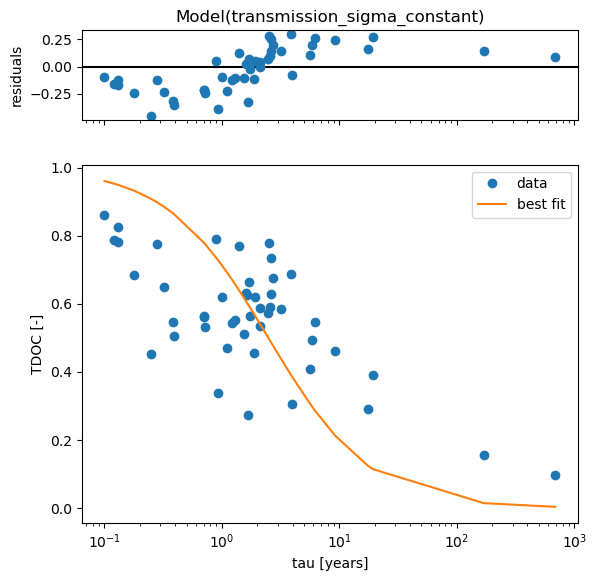

In [10]:
# Plot fit
toc_fit1.plot(xlabel="tau [years]", ylabel="TDOC [-]");
plt.xscale('log')

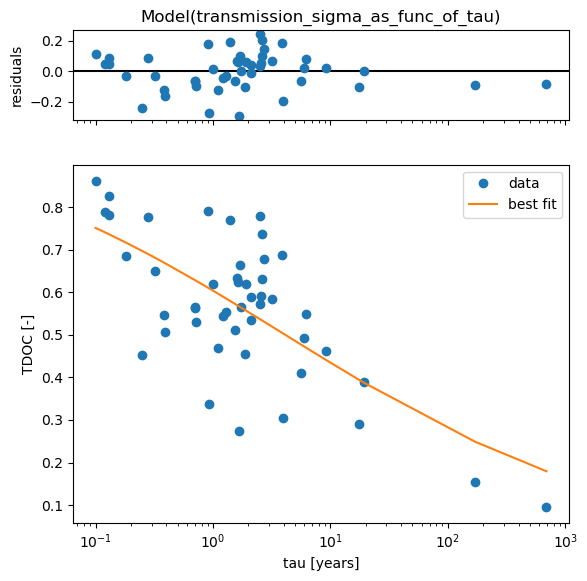

In [11]:
# Plot fit
toc_fit2.plot(xlabel="tau [years]", ylabel="TDOC [-]");
plt.xscale('log')

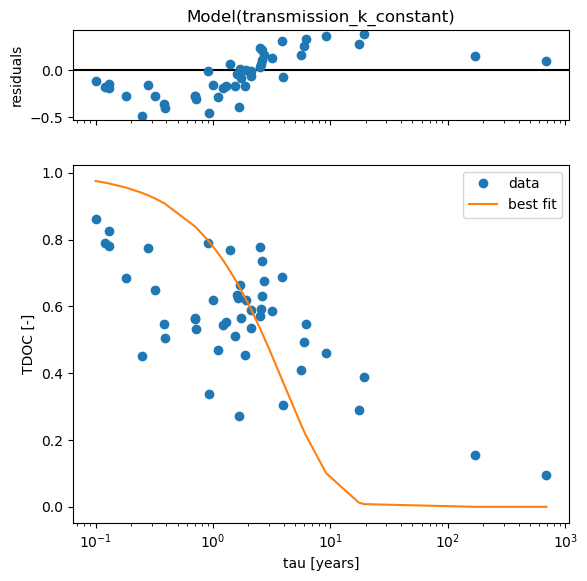

In [12]:
# Plot fit
toc_fit_exp1.plot(xlabel="tau [years]", ylabel="TDOC [-]");
plt.xscale('log')

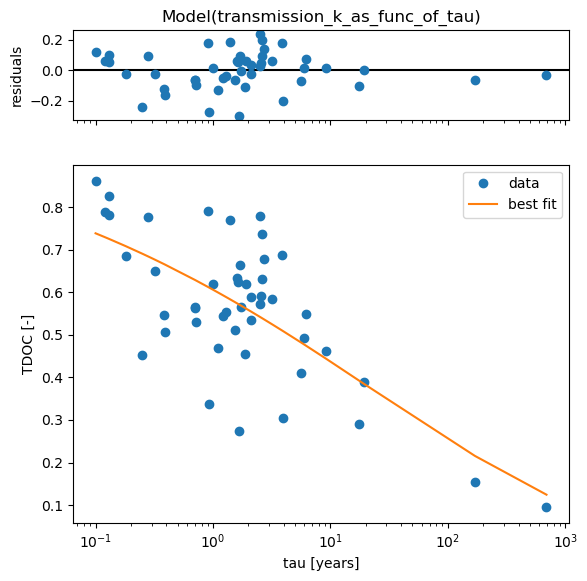

In [13]:
# Plot fit
toc_fit_exp2.plot(xlabel="tau [years]", ylabel="TDOC [-]");
plt.xscale('log')

# Fit TOC, limiting to tau < 10 years

In [14]:
tau_upper = 10
short_tau_df = df.loc[df['tau'] < tau_upper].copy()

print(len(short_tau_df), "lakes in the TOC dataset.")

print("\n\nFit for 'option 1'")
short_fit1 = dr.fit_model(dr.transmission_sigma_constant, short_tau_df, "tau", "TDOC")

print("\n\nFit for 'option 2'")
short_fit2 = dr.fit_model(dr.transmission_sigma_as_func_of_tau, short_tau_df, "tau", "TDOC")

print("\n\nFit for 'exponential decay'")
short_fit_exp1 = dr.fit_model(dr.transmission_k_constant, short_tau_df, "tau", "TDOC")

print("\n\nFit for 'exponential decay'")
short_fit_exp2 = dr.fit_model(dr.transmission_k_as_func_of_tau, short_tau_df, "tau", "TDOC")

43 lakes in the TOC dataset.


Fit for 'option 1'
[[Model]]
    Model(transmission_sigma_constant)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 43
    # variables        = 1
    chi-square         = 1.71853213
    reduced chi-square = 0.04091743
    Akaike info crit   = -136.448373
    Bayesian info crit = -134.687173
    R-squared          = -1.16475791
[[Variables]]
    sigma:  0.41557053 +/- 0.06307218 (15.18%) (init = 0.5)
R2: -1.09


Fit for 'option 2'
[[Model]]
    Model(transmission_sigma_as_func_of_tau)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 43
    # variables        = 2
    chi-square         = 0.64076849
    reduced chi-square = 0.01562850
    Akaike info crit   = -176.870348
    Bayesian info crit = -173.347948
    R-squared          = 0.19285265
[[Variables]]
    a:  0.65689534 +/- 0.05421928 (8.25%) (init = 0.5)
    b: -0.78151169 +/- 0.07412180 (9.

In [15]:
print("\nLRT constant sigma vs time-varying sigma:")
dr.likelihood_ratio_test(short_fit1, short_fit2)


LRT constant sigma vs time-varying sigma:
Likelihood Ratio: 1.0777636424108668
Degrees of Freedom: 1
P-value: 0.299


In [16]:
print("\nLRT constant k vs time-varying k:")
dr.likelihood_ratio_test(short_fit_exp1, short_fit_exp2)


LRT constant k vs time-varying k:
Likelihood Ratio: 1.6253927964034065
Degrees of Freedom: 1
P-value: 0.202


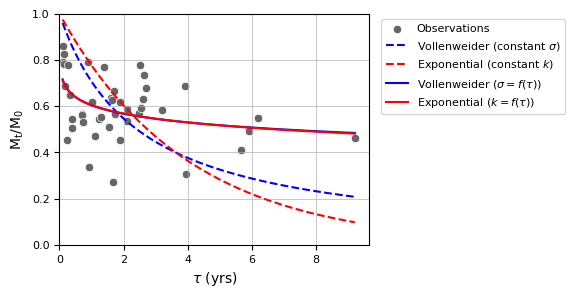

In [17]:
# Plot all models on one figure
fig, ax = plt.subplots(figsize=(4, 3))

# Plot observations
# ax.scatter(short_tau_df['tau'], short_tau_df['TDOC'], label='Observations', color='black')
sn.scatterplot(data=short_tau_df, x='tau', y='TDOC', label='Observations', color='0.4')  # label='Observations', 

# Plot each model's fit
tau_values = np.linspace(short_tau_df['tau'].min(), short_tau_df['tau'].max(), 100000)

ax.plot(tau_values, short_fit1.eval(tau=tau_values), ls='--', label=r'Vollenweider (constant $\sigma$)', color='blue')
ax.plot(tau_values, short_fit_exp1.eval(tau=tau_values), ls='--', label='Exponential (constant $k$)', color='red')
ax.plot(tau_values, short_fit2.eval(tau=tau_values), label=r'Vollenweider ($\sigma = f(\tau$))', color='blue')
ax.plot(tau_values, short_fit_exp2.eval(tau=tau_values), label=r'Exponential ($k = f(\tau$))', color='red')

# # Also plot implied results of Catalan's regression, when rearranged for Cout/Cin
# trans_catalan = np.exp(-0.38 * tau_values ** 0.55)
# ax.plot(tau_values, trans_catalan, label="Exponential decay (Catalan et al. 2016), k=f(t)", color='orange')

# plt.xscale('log')

plt.grid(True, which='major', linewidth=0.5)
ax.set_xlim(xmin=0)
ax.set_ylim(ymin=0, ymax=1)

# Add labels and legend
plt.ylabel('$\mathrm{M_{t}/M_{0}}$', size=10)
plt.xlabel((r'$\tau$ (yrs)'), size=10)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.tick_params(axis='both', which='minor', labelsize=8)

ax.legend(fontsize=8, bbox_to_anchor=(1.65, 1))

# Add the plot location label in bold text to the top right corner
# plt.text(0.98, 0.98, 'd', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

# plt.savefig(f'graphs/model_results_evans-data_all-countries-short-taus_{tau_upper}_legend.png', bbox_inches='tight')
plt.show()

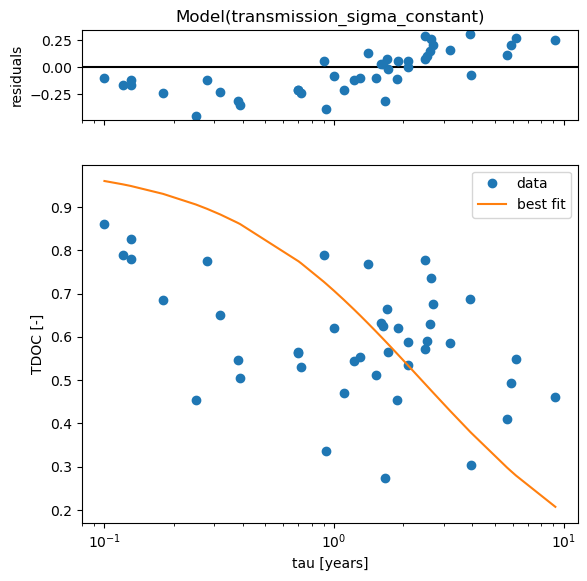

In [18]:
# Plot fit
short_fit1.plot(xlabel="tau [years]", ylabel="TDOC [-]");
plt.xscale('log')

# Fit net production lakes

In [19]:
print("\n\nFit for Voll, constant sigma")
prod_fit1 = dr.fit_model(dr.transmission_sigma_constant, df_neg, "tau", "TDOC")

print("\n\nFit for Voll, sigma = f(tau)")
prod_fit2 = dr.fit_model(dr.transmission_sigma_as_func_of_tau, df_neg, "tau", "TDOC")

print("\n\nFit for 'exponential decay', constant k")
prod_exp_fit1 = dr.fit_model(dr.transmission_k_constant, df_neg, "tau", "TDOC")

print("\n\nFit for 'exponential decay', time-varying k")
prod_exp_fit2 = dr.fit_model(dr.transmission_k_as_func_of_tau, df_neg, "tau", "TDOC")



Fit for Voll, constant sigma
[[Model]]
    Model(transmission_sigma_constant)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 25
    # data points      = 15
    # variables        = 1
    chi-square         = 5.05651836
    reduced chi-square = 0.36117988
    Akaike info crit   = -14.3105804
    Bayesian info crit = -13.6025302
    R-squared          = -1.39529976
[[Variables]]
    sigma: -0.03972777 +/- 0.01182788 (29.77%) (init = 0.5)
R2: -0.02


Fit for Voll, sigma = f(tau)
[[Model]]
    Model(transmission_sigma_as_func_of_tau)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 48
    # data points      = 15
    # variables        = 2
    chi-square         = 1.32931853
    reduced chi-square = 0.10225527
    Akaike info crit   = -32.3507567
    Bayesian info crit = -30.9346563
    R-squared          = 0.37029471
[[Variables]]
    a: -0.36715403 +/- 0.03507263 (9.55%) (init = 0.5)
    b: -0.85337513 +/- 0.05402592 (6.33%) (ini

In [20]:
# Very divergent potential lines above tau = 2. More reliable below.
df_neg_trim = df_neg.loc[df_neg['tau'] < 2, :]

print("\n\nFit for Voll, constant sigma")
prod_fit1 = dr.fit_model(dr.transmission_sigma_constant, df_neg_trim, "tau", "TDOC")

print("\n\nFit for Voll, sigma = f(tau)")
prod_fit2 = dr.fit_model(dr.transmission_sigma_as_func_of_tau, df_neg_trim, "tau", "TDOC")

print("\n\nFit for 'exponential decay', constant k")
prod_exp_fit1 = dr.fit_model(dr.transmission_k_constant, df_neg_trim, "tau", "TDOC")

print("\n\nFit for 'exponential decay', time-varying k")
prod_exp_fit2 = dr.fit_model(dr.transmission_k_as_func_of_tau, df_neg_trim, "tau", "TDOC")



Fit for Voll, constant sigma
[[Model]]
    Model(transmission_sigma_constant)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 18
    # data points      = 13
    # variables        = 1
    chi-square         = 1.10833686
    reduced chi-square = 0.09236140
    Akaike info crit   = -30.0071543
    Bayesian info crit = -29.4422050
    R-squared          = -0.24946813
[[Variables]]
    sigma: -0.34507284 +/- 0.04255131 (12.33%) (init = 0.5)
R2: 0.12


Fit for Voll, sigma = f(tau)
[[Model]]
    Model(transmission_sigma_as_func_of_tau)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 26
    # data points      = 13
    # variables        = 2
    chi-square         = 0.52096633
    reduced chi-square = 0.04736058
    Akaike info crit   = -37.8212498
    Bayesian info crit = -36.6913511
    R-squared          = 0.41269586
[[Variables]]
    a: -0.38273241 +/- 0.03390659 (8.86%) (init = 0.5)
    b: -0.68676026 +/- 0.13354692 (19.45%) (ini

In [21]:
pred = prod_fit2.eval(tau=df_neg_trim['tau'].values)
dr.rs_mae(df_neg_trim['TDOC'], pred, 'Voll, fit 2')

Voll, fit 2:
R2: 0.41 MAE: 0.17


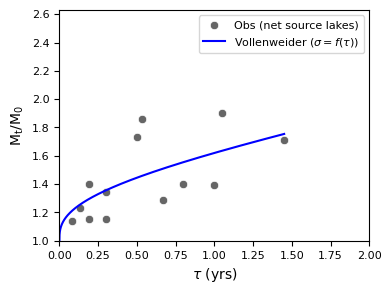

In [22]:
fig, ax = plt.subplots(figsize=(4, 3))

# Plot observations
sn.scatterplot(data=df_neg, x='tau', y='TDOC', color='0.4', label='Obs (net source lakes)')

# Plot each model's fit
tau_values = np.linspace(0, df_neg_trim['tau'].max(), 100000)

# ax.plot(tau_values, prod_fit1.eval(tau=tau_values), ls='--', label=r'Vollenweider (constant $\sigma$)', color='blue')
# ax.plot(tau_values, prod_exp_fit1.eval(tau=tau_values), ls='--', label='Exponential (constant $k$)', color='red')
ax.plot(tau_values, prod_fit2.eval(tau=tau_values), label=r'Vollenweider ($\sigma = f(\tau$))', color='blue')
# ax.plot(tau_values, prod_exp_fit2.eval(tau=tau_values), label=r'Exponential ($k = f(\tau$))', color='red')

# plt.xscale('log')
# plt.yscale('log')
ax.set_xlim(0, 2)

ax.set_ylim(ymin=1)

# plt.grid(True, which='major', linewidth=0.5)

# Add labels and legend
plt.ylabel('$\mathrm{M_{t}/M_{0}}$', size=10)
plt.xlabel((r'$\tau$ (yrs)'), size=10)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.tick_params(axis='both', which='minor', labelsize=8)

ax.legend(fontsize=8)# , bbox_to_anchor=(0.65, 1))

# Add the plot location label in bold text to the top right corner
# plt.text(0.98, 0.98, 'd', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

# plt.savefig(f'graphs/model_results_evans-data_all-countries-short-taus_{tau_upper}_legend.png', bbox_inches='tight')
plt.show()

The points with tau less than around 2 fall roughly on a line. But above there, it's not clear which of the two points is more likely to be correct. I dropped the long tau one originally, but perhaps it's the other one that is off and productivity tends to taper at around 2. Need more data from high productivity lakes to know. Decide to leave the question of productivity for now...